# The placement walk

PSBD-TM and PSBD-RD differ in 2 ways at once. PSBD-TM acts at the attention input and masks whole tokens, PSBD-RD acts on the residual stream after both adds and drops single entries. The headline gain (`start-here.ipynb`) therefore cannot say which of the 2 differences carries it. This notebook separates them, 1 axis at a time, the way `scripts/paper/tab_staircase.py` builds the 4 staircase tables of the paper: first dropout moved around the residual stream, then dropout moved across every position of the block, then the operator changed at a fixed position and token masking moved across positions, and last the winner restricted to bands of blocks. It ends on the ranking of the whole pre-registered basis (`scripts/paper/app_basis.py`) and a position by operator map.

Every number is read from `results/<folder>/psbd_metrics.json` as `cli.analyze` wrote it, fractional PSU at the headline quantile. Nothing here recomputes a sweep. Each table is checked cell by cell against the macros `tab_staircase.py` wrote to `paper/tables/staircase.macros.json`, so a number printed here is the number in the paper. It runs on CPU in about 1 minute, most of it parsing the `psbd_metrics.json` of every clearing model.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import json
import logging
import warnings

logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)
# torchvision's ToTensor deprecation fires once per dataset load and says nothing
# about the numbers below.
warnings.filterwarnings("ignore", message="The transform `ToTensor", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

import scripts.paper._style  # noqa: F401  the figure style every paper figure uses
from scripts.paper._common import word_list

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline


def macro(table, name):
    """1 value of paper/tables/<table>.macros.json, the string headline.tex prints."""
    with open(f"paper/tables/{table}.macros.json") as handle:
        sidecar = json.load(handle)
    value = sidecar["macros"][name]["value"]
    return value


def show_diagram(name, width=None):
    """Embed a TikZ diagram rendered by notebooks/figures/render.py."""
    display(Image(filename=f"notebooks/figures/{name}.png", width=width))

from cli.compare_detectors import psbd_values
from defenses.decision import ADAPTIVE_SHIFT_TARGET, PLACEMENT_MATCH_TARGET, PUBLISHED_PLACEMENT, RECOMMENDED_PLACEMENT
from scripts.paper._common import (
    BOOTSTRAP_RESAMPLES,
    BOOTSTRAP_SEED,
    HEADLINE_KEY,
    attack_label,
    bootstrap_ci,
    clearing_cells,
    fmt,
    load_coverage,
    load_declaration,
    macro_name,
    mean_or_none,
    ordinal,
    placement_words,
    split_placement,
)
import functools

import scripts.paper.app_basis as app_basis
from scripts.paper._style import attack_color, legend_above
from scripts.paper.tab_staircase import TABLES, panel_cells

# ranking_rows re-reads every model's psbd_metrics.json once per placement, 27 times
# over 59 files of about 11 MB, so the reader is memoized for this session.
app_basis.load_psbd_metrics = functools.lru_cache(maxsize=None)(app_basis.load_psbd_metrics)

RESULTS_DIR = "results"
coverage = load_coverage(RESULTS_DIR)
declaration = load_declaration("configs/psbd_basis.json")
print(f"basis declares {len(declaration['basis'])} placements")
print(f"coverage ledger holds {len(coverage['cells'])} panel models, "
      f"{len(clearing_cells(coverage))} clear the attack-success bar")

basis declares 27 placements
coverage ledger holds 98 panel models, 59 clear the attack-success bar


## The positions being compared

The diagram from `start-here.ipynb` names every position. The staircase moves along it: the orange points on the stream, the blue points on the branches and the green point where PSBD-TM acts.

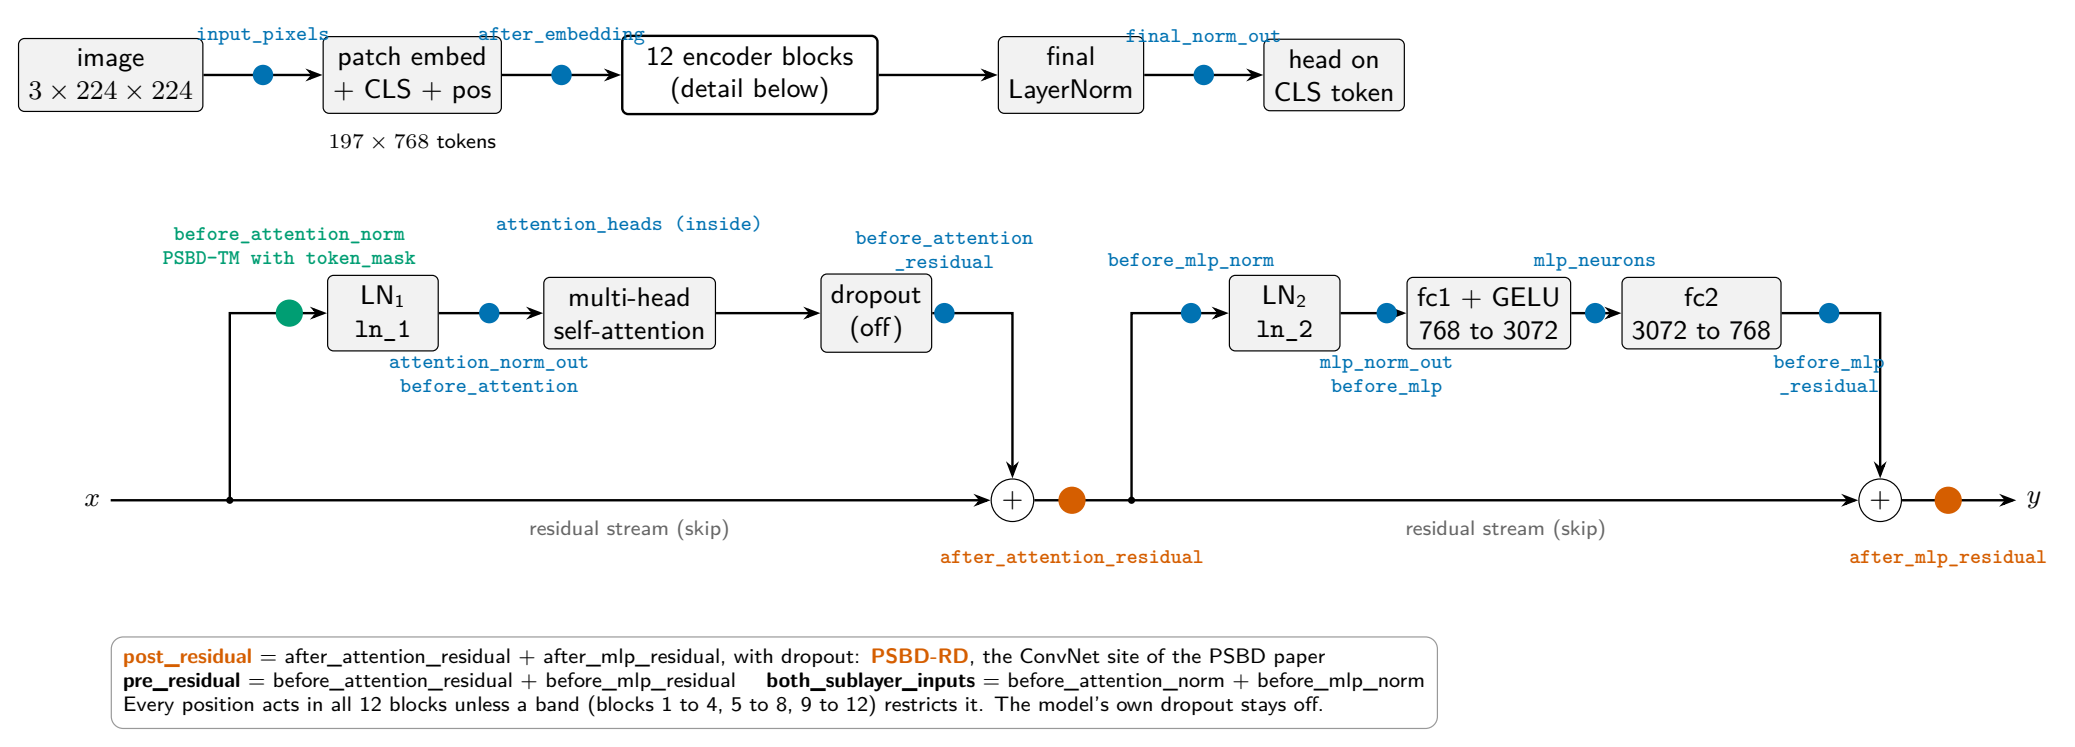

In [2]:
show_diagram("vit_block_positions")

## The model set this notebook reads

A model enters the tables only if PSBD-TM reached both the adaptive and the matched rule on it and PSBD-RD reached the adaptive rule, exactly the filter `tab_staircase.panel_cells` and `tab_headline.py` apply. Every other placement in a table is then averaged over the models of this panel that carry it, so a row's `n` can fall below the panel size when its ladder never reached the adaptive target on some models.

In [3]:
cells = panel_cells(RESULTS_DIR, coverage)
assert str(len(cells)) == macro("staircase", "StaircaseResidualPostResidualN")
panel_frame = pd.DataFrame([{k: c[k] for k in ("folder_name", "dataset", "attack", "poison_rate")} for c in cells])
print(f"{len(cells)} models carry both named placements at the adaptive rule")
models_per_attack = panel_frame.groupby("attack").size().sort_values(ascending=False)  # (attacks,)
clearing_count = len(clearing_cells(coverage))
panel_frame.groupby(["attack", "dataset"]).size().unstack(fill_value=0)

57 models carry both named placements at the adaptive rule


dataset,cifar10,cifar100,gtsrb,tiny
attack,,,,
badnet_a2o,3,3,3,3
blend,3,3,3,3
bpp,3,3,3,3
lf,3,3,3,3
sig,1,0,0,0
tact,2,0,1,0
wanet,2,0,1,2


In [4]:
display(Markdown(rf"""
The panel holds {len(cells)} of the {clearing_count} clearing models, and it is uneven by attack: {word_list([f"{attack_label(a)} {n}" for a, n in models_per_attack.items()])}. A mean over the panel therefore weighs the large attacks most, which is why the per-attack figure further down matters.
"""))


The panel holds 57 of the 59 clearing models, and it is uneven by attack: BadNets 12, Blend 12, BPP 12, LF 12, WaNet 5, TaCT 3 and SIG 1. A mean over the panel therefore weighs the large attacks most, which is why the per-attack figure further down matters.


## Reading 1 placement over the panel

For each placement the helpers below read the adaptive-rule block of every panel model (`psbd_values(report, placement, "adaptive")`, which returns the fractional-PSU quantile reports at the rate the rule chose) and average AUROC, TPR at the 10% quantile and TPR at the 20% quantile. The **paired gain** of a row is the mean over models of (row AUROC minus reference AUROC), taken only on models carrying both, with a 95% bootstrap interval over models (`BOOTSTRAP_RESAMPLES` resamples at `BOOTSTRAP_SEED`). Pairing removes the difference between easy and hard models, which an unpaired difference of means would keep. The first row of every table is its own reference.

In [5]:
def adaptive_auroc(cell, placement_id):
    block = psbd_values(cell["report"], placement_id, "adaptive")
    auroc = None if block is None else block[HEADLINE_KEY]["auroc"]
    return auroc


def measure_placement(cells, placement_id):
    auroc, tpr_10, tpr_20 = [], [], []
    for cell in cells:
        block = psbd_values(cell["report"], placement_id, "adaptive")
        if block is None:
            continue
        auroc.append(block[HEADLINE_KEY]["auroc"])
        tpr_10.append(block["q0.10"]["tpr"])
        tpr_20.append(block["q0.20"]["tpr"])
    measured = {
        "n": len(auroc),
        "auroc": mean_or_none(auroc),
        "tpr_at_10_percent": mean_or_none(tpr_10),
        "tpr_at_20_percent": mean_or_none(tpr_20),
        "below_chance": sum(1 for value in auroc if value < 0.5),
    }
    return measured


def paired_gain(cells, placement_id, reference_id):
    deltas = [
        adaptive_auroc(cell, placement_id) - adaptive_auroc(cell, reference_id)
        for cell in cells
        if adaptive_auroc(cell, placement_id) is not None and adaptive_auroc(cell, reference_id) is not None
    ]
    low, high = bootstrap_ci(deltas, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
    gain = (mean_or_none(deltas), low, high)
    return gain


def staircase_table(cells, rows, table_key):
    reference_id = rows[0][1]
    table_rows = []
    for label, placement_id in rows:
        measured = measure_placement(cells, placement_id)
        gain, low, high = (None, None, None) if placement_id == reference_id else paired_gain(cells, placement_id, reference_id)
        table_rows.append({"placement": label, "id": placement_id, **measured, "gain": gain, "low": low, "high": high})
        check_against_macros(table_key, placement_id, measured, gain, low, high)
    table = pd.DataFrame(table_rows).set_index("placement")
    return table


def check_against_macros(table_key, placement_id, measured, gain, low, high):
    stem = macro_name(f"staircase_{table_key}_{placement_id}")
    assert macro("staircase", f"{stem}N") == str(measured["n"]), stem
    assert macro("staircase", f"{stem}Auroc") == fmt(measured["auroc"]), stem
    if gain is not None:
        assert macro("staircase", f"{stem}Gain") == fmt(gain, signed=True), stem
        assert macro("staircase", f"{stem}GainLow") == fmt(low, signed=True), stem
        assert macro("staircase", f"{stem}GainHigh") == fmt(high, signed=True), stem


def plot_staircase(table, title):
    figure, (mean_axis, gain_axis) = plt.subplots(1, 2, figsize=(10.0, 0.42 * len(table) + 1.2), sharey=True, gridspec_kw={"width_ratios": [1.1, 1]})
    positions = np.arange(len(table))  # (rows,)
    colors = ["#009E73" if i == RECOMMENDED_PLACEMENT else "#D55E00" if i == PUBLISHED_PLACEMENT else "#0072B2" for i in table["id"]]
    mean_axis.barh(positions, table["auroc"], color=colors)
    for position, (auroc, n) in enumerate(zip(table["auroc"], table["n"])):
        mean_axis.text(auroc + 0.005, position, f"{auroc:.3f} (n={n})", va="center", fontsize=6)
    mean_axis.set_yticks(positions, labels=table.index, fontsize=7)
    mean_axis.invert_yaxis()
    mean_axis.set_xlim(0.6, 1.05)
    mean_axis.set_xlabel("mean AUROC, adaptive rule")
    has_gain = table["gain"].notna().to_numpy()  # (rows,)
    errors = np.vstack([(table["gain"] - table["low"])[has_gain], (table["high"] - table["gain"])[has_gain]])  # (2, rows with a gain)
    gain_axis.errorbar(table["gain"][has_gain], positions[has_gain], xerr=errors, fmt="o", color="black", ms=4, lw=1)
    gain_axis.axvline(0, color="black", lw=0.8)
    gain_axis.set_xlabel(f"paired AUROC gain against the first row, 95% interval")
    figure.suptitle(title, fontsize=9)
    figure.tight_layout()
    plt.show()


staircases = {key: (rows, stem) for key, stem, _label, _caption, rows in TABLES}
print("staircase tables from scripts.paper.tab_staircase.TABLES:", list(staircases))

staircase tables from scripts.paper.tab_staircase.TABLES: ['residual', 'dropout_sites', 'operators', 'bands']


## 1. Dropout around the residual stream

The first question is whether the ConvNet placement was transplanted to the wrong point of the ViT block. A ResNet basic block has 1 residual add followed by a ReLU, and the PSBD paper put dropout after it. A ViT block has 2 adds and no activation after either, so "after the residual add" has 3 readings: after both adds (`post_residual`, PSBD-RD), after the attention add only and dropout on the 2 branch outputs just before the adds (`pre_residual`). The table also restricts `pre_residual` to 3 bands of 4 blocks.

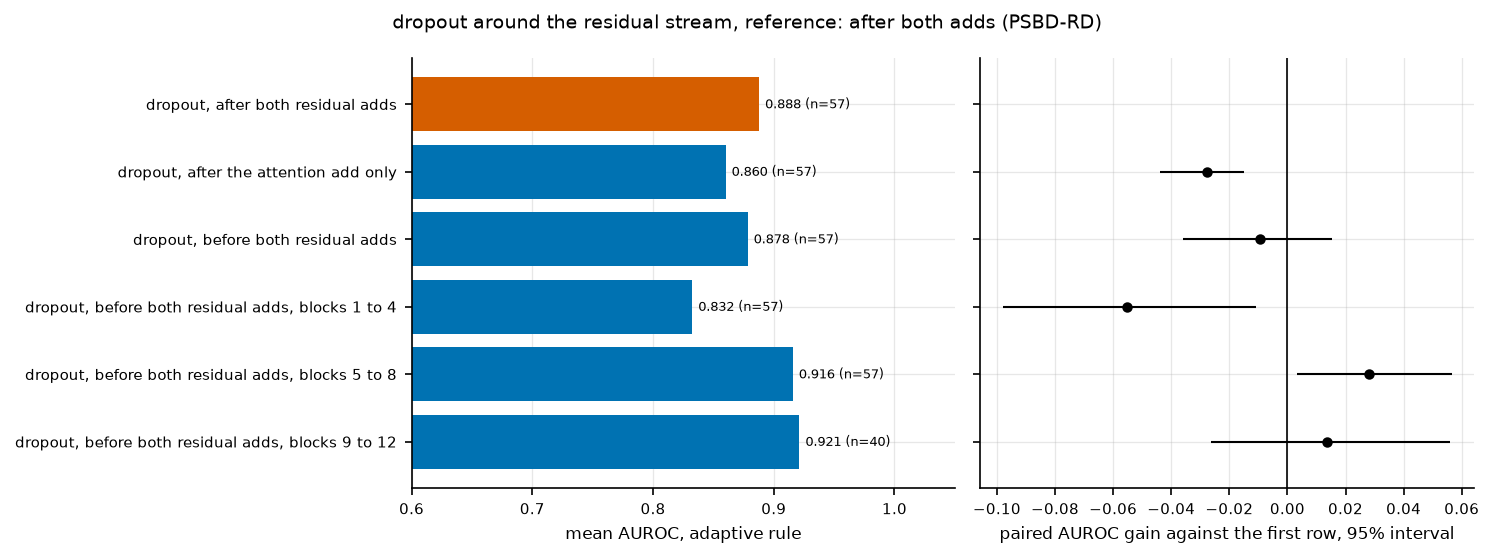

,n,auroc,tpr_at_10_percent,tpr_at_20_percent,below_chance,gain,low,high
placement,,,,,,,,
"dropout, after both residual adds",57,0.888,0.744,0.805,5,NaN,NaN,NaN
"dropout, after the attention add only",57,0.860,0.677,0.764,4,-0.028,-0.044,-0.015
"dropout, before both residual adds",57,0.878,0.707,0.789,3,-0.009,-0.036,0.015
"dropout, before both residual adds, blocks 1 to 4",57,0.832,0.597,0.726,4,-0.055,-0.098,-0.011
"dropout, before both residual adds, blocks 5 to 8",57,0.916,0.773,0.829,3,0.028,0.003,0.056
"dropout, before both residual adds, blocks 9 to 12",40,0.921,0.810,0.862,1,0.014,-0.026,0.056


In [6]:
rows, _stem = staircases["residual"]
residual_table = staircase_table(cells, rows, "residual")
plot_staircase(residual_table, "dropout around the residual stream, reference: after both adds (PSBD-RD)")
residual = residual_table.reset_index().set_index("id")
above_zero = list(residual.index[residual["low"] > 0])
assert above_zero == ["pre_residual_blocks_5_8"], "the reading names blocks 5 to 8 as the 1 row above 0"
residual_table.drop(columns="id").round(3)

In [7]:
display(Markdown(rf"""
Moving dropout within the residual path changes little over all 12 blocks. After the attention add only reads {residual.loc["after_attention_residual", "auroc"]:.3f} against {residual.loc["post_residual", "auroc"]:.3f} for PSBD-RD (gain {residual.loc["after_attention_residual", "gain"]:+.3f}) and before both adds is level ({residual.loc["pre_residual", "gain"]:+.3f}, interval [{residual.loc["pre_residual", "low"]:+.3f}, {residual.loc["pre_residual", "high"]:+.3f}]). Restricting the perturbation to blocks 5 to 8 is the 1 row whose interval sits above 0 ({residual.loc["pre_residual_blocks_5_8", "gain"]:+.3f} [{residual.loc["pre_residual_blocks_5_8", "low"]:+.3f}, {residual.loc["pre_residual_blocks_5_8", "high"]:+.3f}], AUROC {residual.loc["pre_residual_blocks_5_8", "auroc"]:.3f}) and it is the best residual placement of the basis (`\BestResidualName` reads "{macro("best_residual", "BestResidualName")}"). Blocks 9 to 12 reads a high mean over only {residual.loc["pre_residual_blocks_9_12", "n"]} models, the ones where banded dropout reached the {ADAPTIVE_SHIFT_TARGET} shift target, so its mean is flattered by the models it can reach. The figure does not show whether any residual placement closes the gap to PSBD-TM, which the paper reads as {macro("best_residual", "BestResidualGain")} [{macro("best_residual", "BestResidualGainLow").replace("$-$", "−")}, {macro("best_residual", "BestResidualGainHigh")}] for the best of them (`\BestResidualGain`). The next question is whether a non-residual position does better with the same operator.
"""))


Moving dropout within the residual path changes little over all 12 blocks. After the attention add only reads 0.860 against 0.888 for PSBD-RD (gain -0.028) and before both adds is level (-0.009, interval [-0.036, +0.015]). Restricting the perturbation to blocks 5 to 8 is the 1 row whose interval sits above 0 (+0.028 [+0.003, +0.056], AUROC 0.916) and it is the best residual placement of the basis (`\BestResidualName` reads "dropout, before both residual adds, blocks 5 to 8"). Blocks 9 to 12 reads a high mean over only 40 models, the ones where banded dropout reached the 0.8 shift target, so its mean is flattered by the models it can reach. The figure does not show whether any residual placement closes the gap to PSBD-TM, which the paper reads as +0.037 [−0.006, +0.083] for the best of them (`\BestResidualGain`). The next question is whether a non-residual position does better with the same operator.


## 2. Dropout moved across every position

The operator stays dropout. Only where it attaches changes: the stream after both adds, the branch outputs before the adds, the attention input before its LayerNorm, the attention input after its LayerNorm, the MLP input before its LayerNorm and the embedding output (once, before block 1).

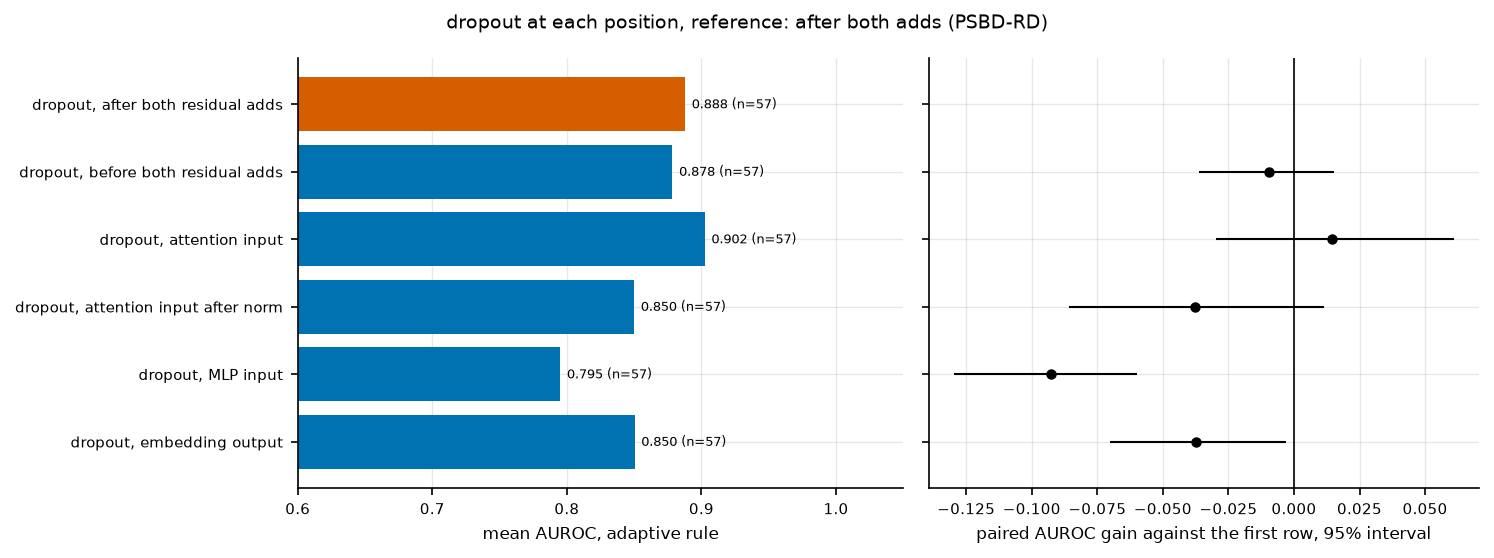

,n,auroc,tpr_at_10_percent,tpr_at_20_percent,below_chance,gain,low,high
placement,,,,,,,,
"dropout, after both residual adds",57,0.888,0.744,0.805,5,NaN,NaN,NaN
"dropout, before both residual adds",57,0.878,0.707,0.789,3,-0.009,-0.036,0.015
"dropout, attention input",57,0.902,0.709,0.816,1,0.015,-0.030,0.061
"dropout, attention input after norm",57,0.850,0.643,0.757,4,-0.038,-0.086,0.012
"dropout, MLP input",57,0.795,0.567,0.690,9,-0.093,-0.130,-0.060
"dropout, embedding output",57,0.850,0.582,0.730,2,-0.038,-0.070,-0.003


In [8]:
rows, _stem = staircases["dropout_sites"]
site_table = staircase_table(cells, rows, "dropout_sites")
plot_staircase(site_table, "dropout at each position, reference: after both adds (PSBD-RD)")
sites = site_table.reset_index().set_index("id")
best_site, worst_site = sites["auroc"].idxmax(), sites["auroc"].idxmin()
assert (best_site, worst_site) == ("before_attention_norm", "before_mlp_norm"), "the reading names these 2 positions"
site_table.drop(columns="id").round(3)

In [9]:
display(Markdown(rf"""
With dropout fixed, the attention input before the norm is the best position ({sites.loc[best_site, "auroc"]:.3f}) and the MLP input the worst ({sites.loc[worst_site, "auroc"]:.3f}, {sites.loc[worst_site, "gain"]:+.3f} [{sites.loc[worst_site, "low"]:+.3f}, {sites.loc[worst_site, "high"]:+.3f}]). Moving dropout from the stream to the attention input gains {sites.loc[best_site, "gain"]:+.3f} with an interval of [{sites.loc[best_site, "low"]:+.3f}, {sites.loc[best_site, "high"]:+.3f}], so the position alone, with the operator held at dropout, does not produce the headline gain. The figure does not show what happens when the operator changes at the attention input, the next table.
"""))


With dropout fixed, the attention input before the norm is the best position (0.902) and the MLP input the worst (0.795, -0.093 [-0.130, -0.060]). Moving dropout from the stream to the attention input gains +0.015 with an interval of [-0.030, +0.061], so the position alone, with the operator held at dropout, does not produce the headline gain. The figure does not show what happens when the operator changes at the attention input, the next table.


## 3. The operator at a fixed position, then token masking moved across positions

The first 4 rows hold the position at the attention input before its LayerNorm and change the operator: token mask (PSBD-TM), channel mask, Gaussian noise and dropout. The next rows hold token masking fixed and move it: the attention branch output before the add (the "twin"), both sublayer inputs at once, the MLP input, the stream after the attention add. The last rows are the remaining structured and ported operators, and PSBD-RD closes the table. The reference is PSBD-TM, so every gain is negative when PSBD-TM wins.

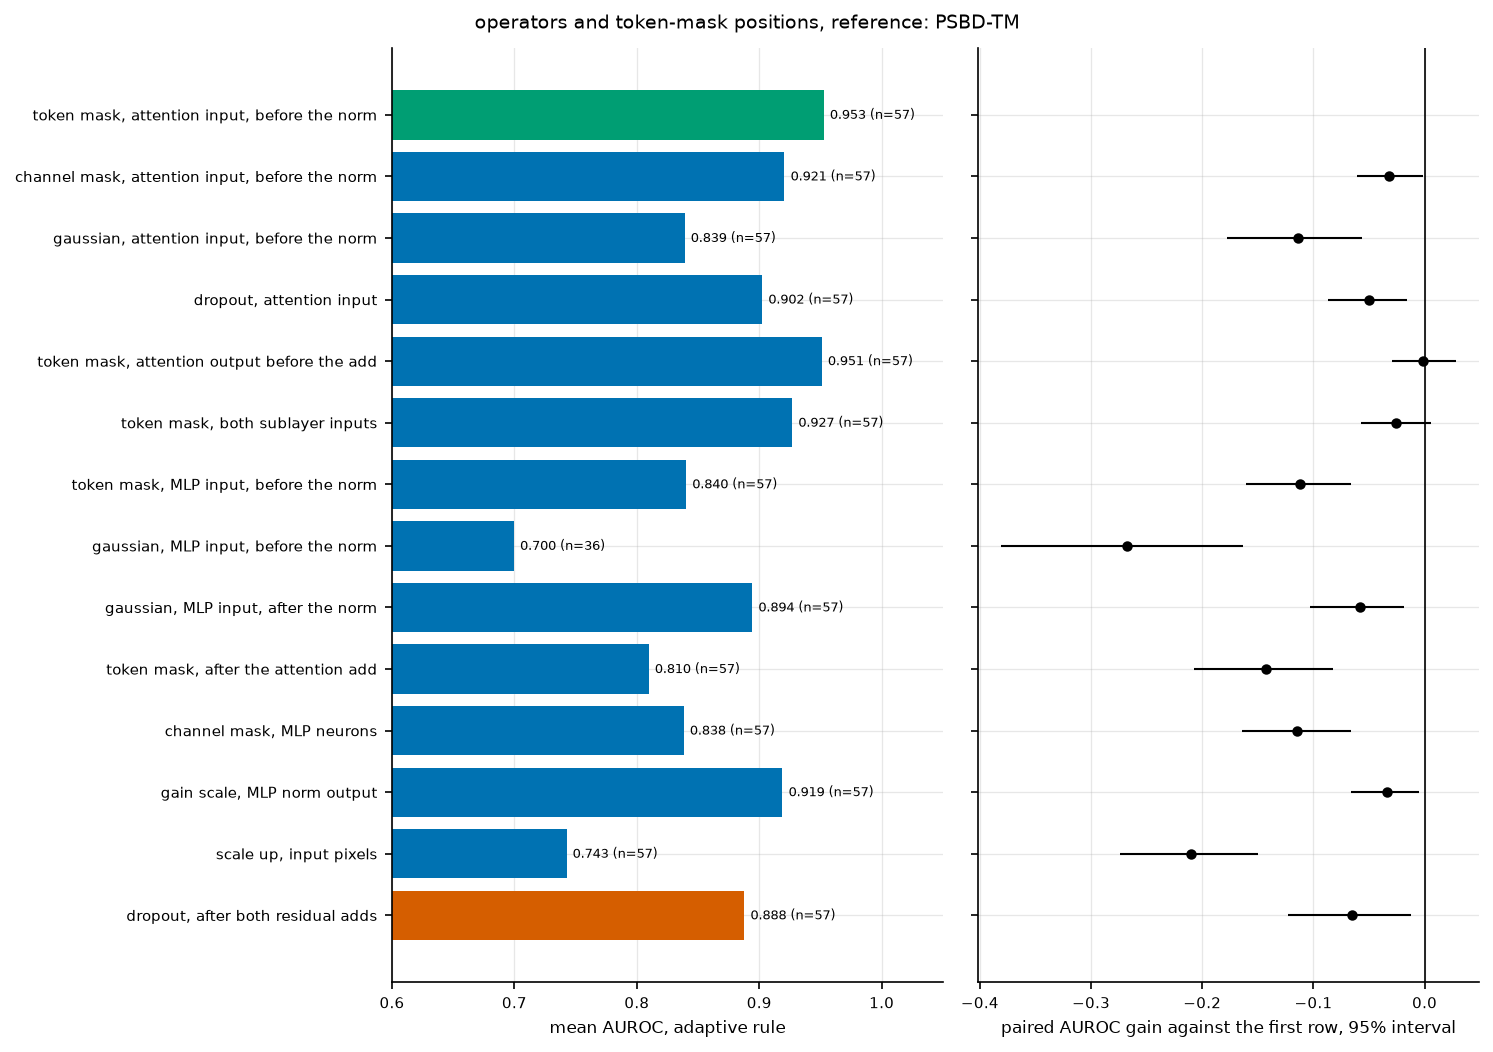

,n,auroc,tpr_at_10_percent,tpr_at_20_percent,below_chance,gain,low,high
placement,,,,,,,,
"token mask, attention input, before the norm",57,0.953,0.873,0.902,2,NaN,NaN,NaN
"channel mask, attention input, before the norm",57,0.921,0.765,0.841,0,-0.032,-0.061,-0.002
"gaussian, attention input, before the norm",57,0.839,0.595,0.712,6,-0.114,-0.178,-0.056
"dropout, attention input",57,0.902,0.709,0.816,1,-0.050,-0.087,-0.016
"token mask, attention output before the add",57,0.951,0.846,0.909,0,-0.002,-0.030,0.028
"token mask, both sublayer inputs",57,0.927,0.792,0.850,0,-0.026,-0.057,0.006
"token mask, MLP input, before the norm",57,0.840,0.555,0.734,3,-0.112,-0.161,-0.066
"gaussian, MLP input, before the norm",36,0.700,0.387,0.559,8,-0.268,-0.381,-0.163
"gaussian, MLP input, after the norm",57,0.894,0.748,0.818,5,-0.058,-0.103,-0.018


In [10]:
rows, _stem = staircases["operators"]
operator_table = staircase_table(cells, rows, "operators")
plot_staircase(operator_table, "operators and token-mask positions, reference: PSBD-TM")
operators = operator_table.reset_index().set_index("id")
same_site = ["before_attention_norm_channel_mask", "before_attention_norm_gaussian", "before_attention_norm"]
assert (operators.loc[same_site, "high"] < 0).all(), "the reading says every other operator at the input loses with an interval below 0"
twin_row = operators.loc["before_attention_residual_token_mask"]
assert twin_row["low"] < 0 < twin_row["high"], "the reading calls the twin a tie"
operator_table.drop(columns="id").round(3)

In [11]:
display(Markdown(rf"""
At the attention input token masking beats every other operator with an interval below 0: channel masking {operators.loc["before_attention_norm_channel_mask", "gain"]:+.3f}, dropout {operators.loc["before_attention_norm", "gain"]:+.3f}, Gaussian noise {operators.loc["before_attention_norm_gaussian", "gain"]:+.3f}. So the operator matters at this position, and together with table 2 the headline gain needs both halves, the attention input and whole-token removal. Token masking moved onto the stream after the attention add falls to {operators.loc["after_attention_residual_token_mask", "auroc"]:.3f} and at the MLP input to {operators.loc["before_mlp_norm_token_mask", "auroc"]:.3f}, while its twin on the attention branch output before the add ties PSBD-TM ({twin_row["gain"]:+.3f} [{twin_row["low"]:+.3f}, {twin_row["high"]:+.3f}]). The twin and PSBD-TM both act on the attention branch, and they differ on Swin (`swin-and-robustness.ipynb`). Gaussian noise at the MLP input before its norm reaches the shift target on only {operators.loc["before_mlp_norm_gaussian", "n"]} models. The table does not show why token masking at the attention input works, which `mechanism.ipynb` measures. It also does not show whether acting in fewer blocks would do better, the next table.
"""))


At the attention input token masking beats every other operator with an interval below 0: channel masking -0.032, dropout -0.050, Gaussian noise -0.114. So the operator matters at this position, and together with table 2 the headline gain needs both halves, the attention input and whole-token removal. Token masking moved onto the stream after the attention add falls to 0.810 and at the MLP input to 0.840, while its twin on the attention branch output before the add ties PSBD-TM (-0.002 [-0.030, +0.028]). The twin and PSBD-TM both act on the attention branch, and they differ on Swin (`swin-and-robustness.ipynb`). Gaussian noise at the MLP input before its norm reaches the shift target on only 36 models. The table does not show why token masking at the attention input works, which `mechanism.ipynb` measures. It also does not show whether acting in fewer blocks would do better, the next table.


## 4. Banding the winner

Everything above perturbs every block. This restricts token masking at the attention input to blocks 1 to 4, 5 to 8 or 9 to 12.

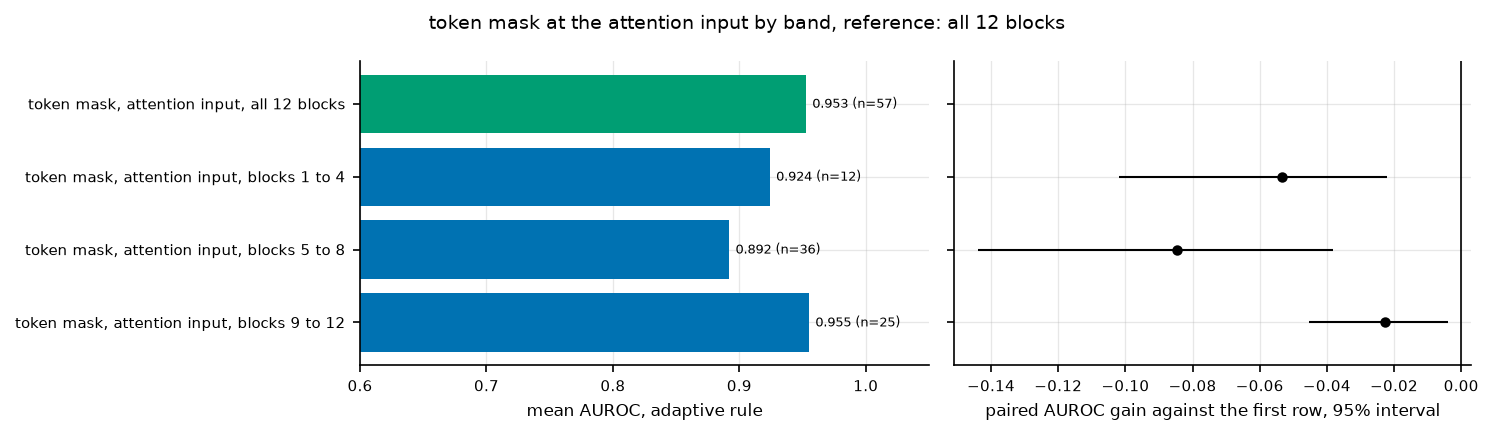

,n,auroc,tpr_at_10_percent,tpr_at_20_percent,below_chance,gain,low,high
placement,,,,,,,,
"token mask, attention input, all 12 blocks",57,0.953,0.873,0.902,2,NaN,NaN,NaN
"token mask, attention input, blocks 1 to 4",12,0.924,0.795,0.902,0,-0.053,-0.102,-0.022
"token mask, attention input, blocks 5 to 8",36,0.892,0.791,0.867,2,-0.085,-0.144,-0.038
"token mask, attention input, blocks 9 to 12",25,0.955,0.891,0.936,0,-0.023,-0.045,-0.004


In [12]:
rows, _stem = staircases["bands"]
band_table = staircase_table(cells, rows, "bands")
plot_staircase(band_table, "token mask at the attention input by band, reference: all 12 blocks")
bands = band_table.reset_index().set_index("id")
band_ids = [i for i in bands.index if i != RECOMMENDED_PLACEMENT]
assert (bands.loc[band_ids, "high"] < 0).all(), "the reading says every band loses with an interval below 0"
least_loss = bands.loc[band_ids, "gain"].idxmax()
band_table.drop(columns="id").round(3)

In [13]:
display(Markdown(rf"""
At the adaptive rule the bands are hard to read, because masking 4 blocks rarely shifts {ADAPTIVE_SHIFT_TARGET:.0%} of clean predictions. The target is reached on {word_list([f"{r['n']} models for {r['placement'].split(', ')[-1]}" for _, r in band_table.reset_index().iloc[1:].iterrows()])}, so each unpaired mean is taken over a different, easier subset. The paired gains settle it: on the models each band reaches, every band loses to all 12 blocks with an interval below 0, {bands.loc[least_loss, "placement"].split(", ")[-1]} by the least ({bands.loc[least_loss, "gain"]:+.3f} [{bands.loc[least_loss, "low"]:+.3f}, {bands.loc[least_loss, "high"]:+.3f}]). `depth-bands.ipynb` reads the same bands at the matched {PLACEMENT_MATCH_TARGET} rule, which every band reaches on every model. The figure does not show where in depth the trigger is read, which `mechanism.ipynb` measures directly.
"""))


At the adaptive rule the bands are hard to read, because masking 4 blocks rarely shifts 80% of clean predictions. The target is reached on 12 models for blocks 1 to 4, 36 models for blocks 5 to 8 and 25 models for blocks 9 to 12, so each unpaired mean is taken over a different, easier subset. The paired gains settle it: on the models each band reaches, every band loses to all 12 blocks with an interval below 0, blocks 9 to 12 by the least (-0.023 [-0.045, -0.004]). `depth-bands.ipynb` reads the same bands at the matched 0.6 rule, which every band reaches on every model. The figure does not show where in depth the trigger is read, which `mechanism.ipynb` measures directly.


## Where the gain comes from, per attack

A mean over the panel hides which attacks each placement handles. The heatmap reads 5 placements from the tables above per attack: PSBD-TM, its twin, dropout at the attention input, the best residual placement and PSBD-RD, each averaged over the panel models of that attack at the adaptive rule.

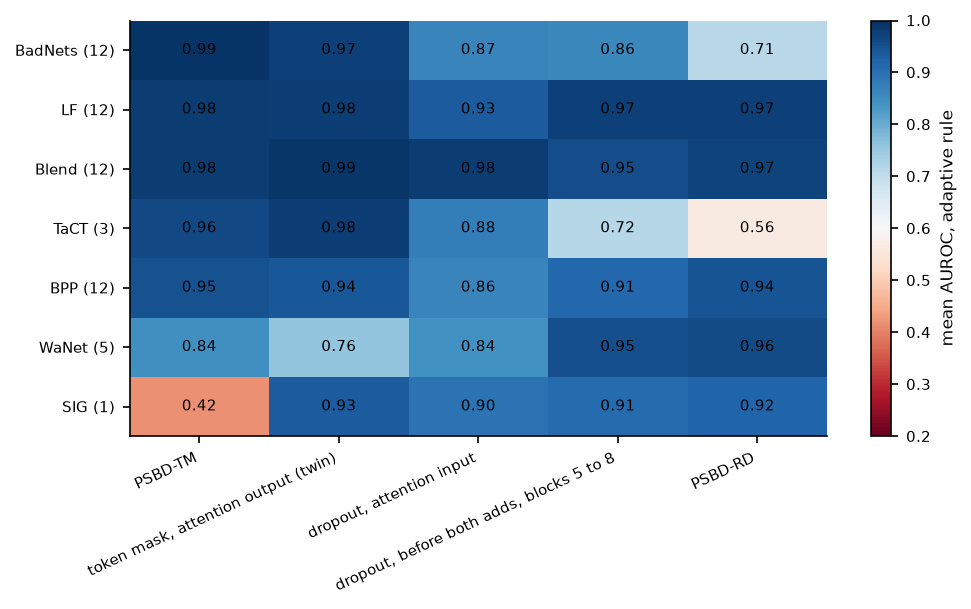

,PSBD-TM,"token mask, attention output (twin)","dropout, attention input","dropout, before both adds, blocks 5 to 8",PSBD-RD
attack,,,,,
BadNets,0.992,0.973,0.865,0.857,0.712
LF,0.980,0.977,0.934,0.974,0.974
Blend,0.978,0.991,0.979,0.953,0.971
TaCT,0.962,0.976,0.877,0.715,0.563
BPP,0.948,0.939,0.863,0.915,0.945
WaNet,0.845,0.759,0.843,0.951,0.956
SIG,0.418,0.934,0.896,0.907,0.919


In [14]:
ATTACK_PLACEMENTS = {
    "PSBD-TM": RECOMMENDED_PLACEMENT,
    "token mask, attention output (twin)": "before_attention_residual_token_mask",
    "dropout, attention input": "before_attention_norm",
    "dropout, before both adds, blocks 5 to 8": "pre_residual_blocks_5_8",
    "PSBD-RD": PUBLISHED_PLACEMENT,
}
per_model = pd.DataFrame(
    [
        {"attack": attack_label(cell["attack"]), **{label: adaptive_auroc(cell, placement) for label, placement in ATTACK_PLACEMENTS.items()}}
        for cell in cells
    ]
)
per_attack = per_model.groupby("attack").mean()  # (attacks, placements)
models_per_attack = per_model.groupby("attack").size()
per_attack = per_attack.sort_values("PSBD-TM", ascending=False)

figure, axis = plt.subplots(figsize=(7.5, 3.6))
image = axis.imshow(per_attack.to_numpy(), cmap="RdBu", vmin=0.2, vmax=1.0, aspect="auto")
for r in range(per_attack.shape[0]):
    for c in range(per_attack.shape[1]):
        value = per_attack.iat[r, c]
        axis.text(c, r, "" if pd.isna(value) else f"{value:.2f}", ha="center", va="center", fontsize=7)
axis.set_xticks(range(per_attack.shape[1]), labels=per_attack.columns, rotation=25, ha="right", fontsize=7)
axis.set_yticks(range(per_attack.shape[0]), labels=[f"{a} ({models_per_attack[a]})" for a in per_attack.index])
axis.grid(False)
figure.colorbar(image, ax=axis, label="mean AUROC, adaptive rule")
plt.show()
attack_gain = (per_attack["PSBD-TM"] - per_attack["PSBD-RD"]).sort_values(ascending=False)  # (attacks,)
assert set(attack_gain.index[:2]) == {"BadNets", "TaCT"}, "the reading names the 2 patch triggers as the largest gains"
rd_ahead = list(attack_gain.index[attack_gain < 0])
global_rows = [a for a in ("Blend", "LF", "BPP") if a in per_attack.index]
per_attack.round(3)

In [15]:
display(Markdown(rf"""
The largest gains of PSBD-TM over PSBD-RD sit in the 2 patch-trigger rows, BadNets ({per_attack.loc["BadNets", "PSBD-TM"]:.3f} against {per_attack.loc["BadNets", "PSBD-RD"]:.3f}) and TaCT ({per_attack.loc["TaCT", "PSBD-TM"]:.3f} against {per_attack.loc["TaCT", "PSBD-RD"]:.3f}). On {word_list(global_rows)} every placement reads at least {per_attack.loc[global_rows].min().min():.3f}, so the order among them is small. PSBD-RD leads PSBD-TM on {word_list(rd_ahead)}: on WaNet {per_attack.loc["WaNet", "PSBD-RD"]:.3f} against {per_attack.loc["WaNet", "PSBD-TM"]:.3f}, and on the single SIG model PSBD-TM falls to {per_attack.loc["SIG", "PSBD-TM"]:.3f} while the other placements read between {per_attack.loc["SIG"].drop("PSBD-TM").min():.3f} and {per_attack.loc["SIG"].drop("PSBD-TM").max():.3f}. This is the split the paper reports: token masking helps where the trigger lives in a few tokens and ties or trails where the trigger is spread over the image. The SIG row is {models_per_attack["SIG"]} model and the TaCT row {models_per_attack["TaCT"]}, so those 2 rows carry little weight. The figure does not show the poison rate, which `start-here.ipynb` splits (`\GainsLowestRate`, `\GainsHighestRate`).
"""))


The largest gains of PSBD-TM over PSBD-RD sit in the 2 patch-trigger rows, BadNets (0.992 against 0.712) and TaCT (0.962 against 0.563). On Blend, LF and BPP every placement reads at least 0.863, so the order among them is small. PSBD-RD leads PSBD-TM on WaNet and SIG: on WaNet 0.956 against 0.845, and on the single SIG model PSBD-TM falls to 0.418 while the other placements read between 0.896 and 0.934. This is the split the paper reports: token masking helps where the trigger lives in a few tokens and ties or trails where the trigger is spread over the image. The SIG row is 1 model and the TaCT row 3, so those 2 rows carry little weight. The figure does not show the poison rate, which `start-here.ipynb` splits (`\GainsLowestRate`, `\GainsHighestRate`).


## The full basis, ranked

The 4 tables above are chosen slices. The basis is the complete pre-registered set of placements in `configs/psbd_basis.json`, declared before the panel was read so that the winner could not be picked after the fact. The figure ranks all of them by mean AUROC at the adaptive rule over the clearing models each reaches (`scripts.paper.app_basis.ranking_rows`, the same reader `fig_basis_ranking.py` uses), with the number of models written beside each bar and the matched-rule mean as a dot.

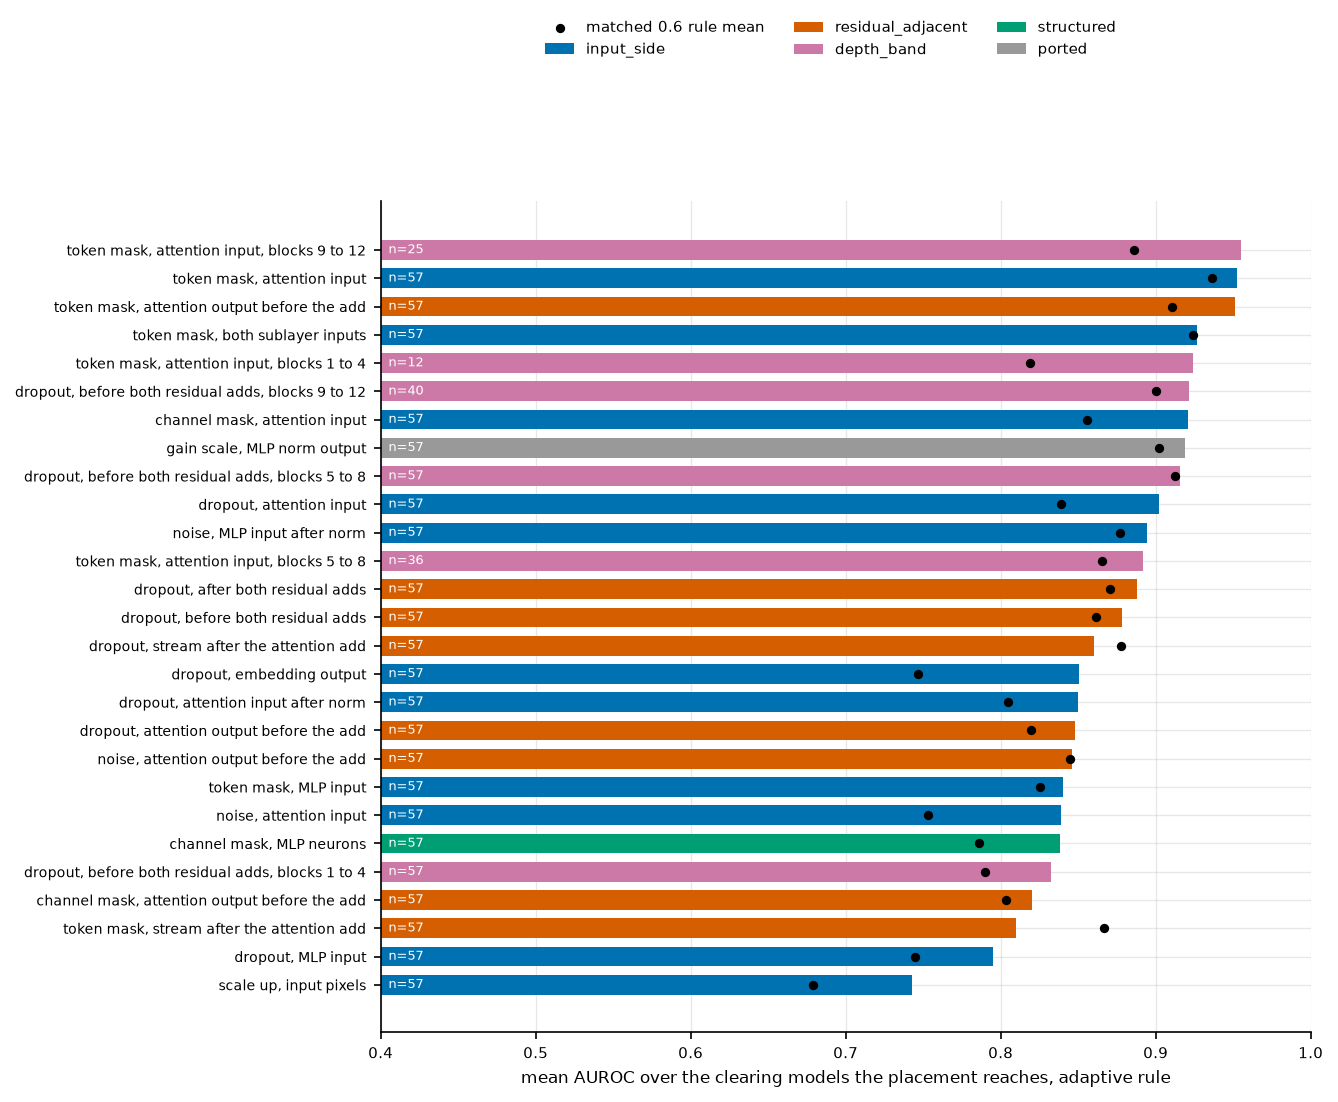

27 placements ranked, PSBD-TM 2 at the adaptive rule and 1 at the matched rule, PSBD-RD 13
top at the adaptive rule: before_attention_norm_blocks_9_12_token_mask (0.955, n=25)


In [16]:
_rows, ordered = app_basis.ranking_rows(RESULTS_DIR, clearing_cells(coverage), declaration["basis"])
ranked = [placement for placement in ordered if ordered[placement]["adaptive_mean"] is not None]
family_colors = {"input_side": "#0072B2", "residual_adjacent": "#D55E00", "depth_band": "#CC79A7", "structured": "#009E73", "ported": "#999999"}

figure, axis = plt.subplots(figsize=(8.0, 7.2))
positions = np.arange(len(ranked))  # (placements,)
axis.barh(positions, [ordered[p]["adaptive_mean"] for p in ranked], color=[family_colors[ordered[p]["family"]] for p in ranked], height=0.7)
axis.scatter([ordered[p]["matched_mean"] or np.nan for p in ranked], positions, color="black", s=12, zorder=3, label=f"matched {PLACEMENT_MATCH_TARGET} rule mean")
for position, placement in enumerate(ranked):
    axis.text(0.405, position, f"n={ordered[placement]['adaptive_n']}", va="center", fontsize=6, color="white")
axis.set_yticks(positions, labels=[placement_words(p) for p in ranked], fontsize=6.5)
axis.invert_yaxis()
axis.set_xlim(0.4, 1.0)
axis.set_xlabel("mean AUROC over the clearing models the placement reaches, adaptive rule")
for family, color in family_colors.items():
    axis.barh([0], [0], color=color, label=family)
legend_above(figure, [axis], columns=3)
plt.show()

recommended_rank = ranked.index(RECOMMENDED_PLACEMENT) + 1
published_rank = ranked.index(PUBLISHED_PLACEMENT) + 1
assert str(recommended_rank) == macro("basis", "BasisRankRecommendedAdaptive")
assert str(published_rank) == macro("basis", "BasisRankPublishedAdaptive")
matched_order = sorted(ranked, key=lambda p: -(ordered[p]["matched_mean"] or 0))
assert str(matched_order.index(RECOMMENDED_PLACEMENT) + 1) == macro("basis", "BasisRankRecommendedMatched")
print(f"{len(ranked)} placements ranked, PSBD-TM {recommended_rank} at the adaptive rule and "
      f"{matched_order.index(RECOMMENDED_PLACEMENT) + 1} at the matched rule, PSBD-RD {published_rank}")
print(f"top at the adaptive rule: {ranked[0]} ({ordered[ranked[0]]['adaptive_mean']:.3f}, n={ordered[ranked[0]]['adaptive_n']})")
top_five_token_masks = sum("token_mask" in p for p in ranked[:5])

In [17]:
display(Markdown(rf"""
PSBD-TM ranks {ordinal(recommended_rank)} of {len(ranked)} at the adaptive rule and {ordinal(matched_order.index(RECOMMENDED_PLACEMENT) + 1)} at the matched rule (`\BasisRankRecommendedAdaptive`, `\BasisRankRecommendedMatched`). PSBD-RD ranks {ordinal(published_rank)}. The placement ranked 1st at the adaptive rule is `{ranked[0]}`, which reaches the adaptive target on {ordered[ranked[0]]["adaptive_n"]} models against {ordered[RECOMMENDED_PLACEMENT]["adaptive_n"]} for PSBD-TM, so its mean is taken over a subset. The matched dots, where every placement reads on almost every model, put `{matched_order[0]}` first. Token masks fill {top_five_token_masks} of the top 5 rows at the adaptive rule. The figure does not separate position from operator, the last figure does.
"""))


PSBD-TM ranks 2nd of 27 at the adaptive rule and 1st at the matched rule (`\BasisRankRecommendedAdaptive`, `\BasisRankRecommendedMatched`). PSBD-RD ranks 13th. The placement ranked 1st at the adaptive rule is `before_attention_norm_blocks_9_12_token_mask`, which reaches the adaptive target on 25 models against 57 for PSBD-TM, so its mean is taken over a subset. The matched dots, where every placement reads on almost every model, put `before_attention_norm_token_mask` first. Token masks fill 5 of the top 5 rows at the adaptive rule. The figure does not separate position from operator, the last figure does.


## Position against operator

The last figure lays the all-blocks basis placements out on a grid, 1 row per position and 1 column per operator, colored by mean AUROC at the matched rule. The matched rule puts every placement at the same measured disturbance of the clean model, which is the canonical device for comparing placements (`PLACEMENT_MATCH_TARGET`). A row that changes color across its columns says the operator matters at that position, and a column that changes down its rows says the position matters for that operator.

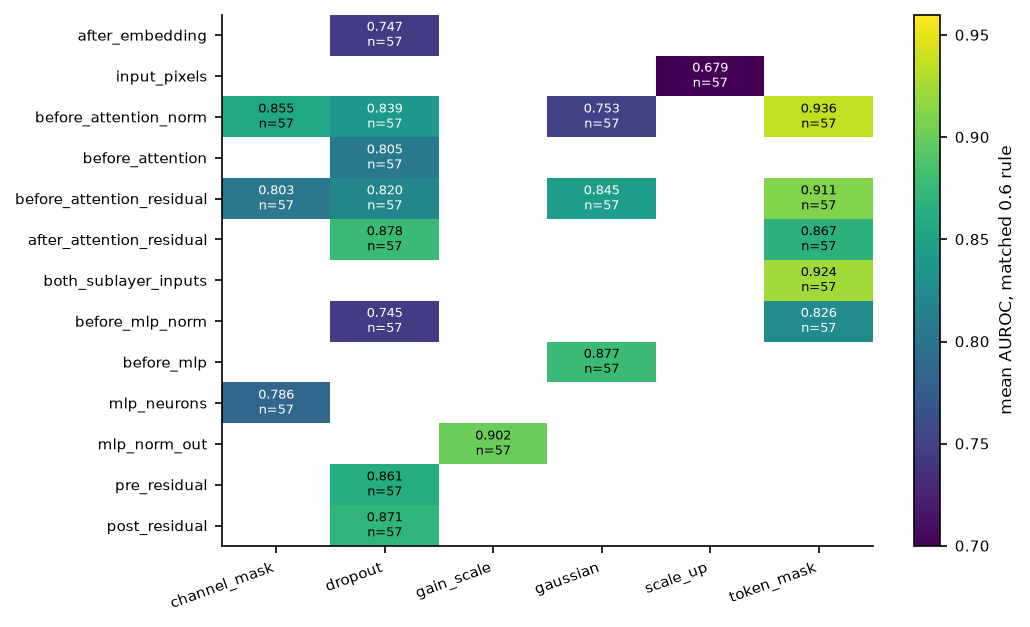

range across operators at before_attention_norm, matched rule: 0.183 | macro OperatorRangeAttentionNormMatched 0.183
range across token_mask positions, matched rule: 0.110 | macro PositionRangeTokenMaskMatched 0.110


In [18]:
grid_rows = []
for placement, stats in ordered.items():
    parsed = split_placement(placement)
    if parsed["block_range"] is not None or stats["matched_mean"] is None:
        continue
    grid_rows.append({"position": parsed["position"], "operator": parsed["operator"], "auroc": stats["matched_mean"], "n": stats["matched_n"]})
grid = pd.DataFrame(grid_rows).pivot(index="position", columns="operator", values="auroc")
grid_n = pd.DataFrame(grid_rows).pivot(index="position", columns="operator", values="n")
position_order = [p for p in ("after_embedding", "input_pixels", "before_attention_norm", "before_attention", "before_attention_residual", "after_attention_residual", "both_sublayer_inputs", "before_mlp_norm", "before_mlp", "mlp_neurons", "mlp_norm_out", "pre_residual", "post_residual") if p in grid.index]
grid = grid.reindex(position_order)
grid_n = grid_n.reindex(position_order)

figure, axis = plt.subplots(figsize=(7.0, 4.6))
image = axis.imshow(grid.to_numpy(dtype=float), cmap="viridis", vmin=0.7, vmax=0.96, aspect="auto")
for r in range(grid.shape[0]):
    for c in range(grid.shape[1]):
        value = grid.iat[r, c]
        if not pd.isna(value):
            axis.text(c, r, f"{value:.3f}\nn={int(grid_n.iat[r, c])}", ha="center", va="center", fontsize=6, color="white" if value < 0.85 else "black")
axis.set_xticks(range(grid.shape[1]), labels=grid.columns, rotation=20, ha="right")
axis.set_yticks(range(grid.shape[0]), labels=grid.index, fontsize=7)
axis.grid(False)
figure.colorbar(image, ax=axis, label=f"mean AUROC, matched {PLACEMENT_MATCH_TARGET} rule")
plt.show()
print("range across operators at before_attention_norm, matched rule:",
      f"{grid.loc['before_attention_norm'].max() - grid.loc['before_attention_norm'].min():.3f}",
      "| macro OperatorRangeAttentionNormMatched", macro("basis", "OperatorRangeAttentionNormMatched"))
print("range across token_mask positions, matched rule:",
      f"{grid['token_mask'].max() - grid['token_mask'].min():.3f}",
      "| macro PositionRangeTokenMaskMatched", macro("basis", "PositionRangeTokenMaskMatched"))
operator_range = grid.loc["before_attention_norm"].max() - grid.loc["before_attention_norm"].min()
position_range = grid["token_mask"].max() - grid["token_mask"].min()

In [19]:
display(Markdown(rf"""
Empty cells are combinations the basis does not declare. At the matched rule the range across operators at the attention input is {operator_range:.3f} and the range across positions for token masking is {position_range:.3f} (`\OperatorRangeAttentionNormMatched`, `\PositionRangeTokenMaskMatched`), so neither axis reduces to the other. The paper's own pair of contrasts is `\GaussianMinusTokenMaskAttentionNorm` ({macro("operators", "GaussianMinusTokenMaskAttentionNorm").replace("$-$", "−")}, noise minus token masking at the attention input) and `\AttentionInputMinusMlpInputTokenMask` ({macro("operators", "AttentionInputMinusMlpInputTokenMask")}, the attention input minus the MLP input for token masking), both at the matched rule in `paper/tables/operators.macros.json`. The grid does not show paired intervals, which those macros carry. It also averages over each cell's own model count.
"""))


Empty cells are combinations the basis does not declare. At the matched rule the range across operators at the attention input is 0.183 and the range across positions for token masking is 0.110 (`\OperatorRangeAttentionNormMatched`, `\PositionRangeTokenMaskMatched`), so neither axis reduces to the other. The paper's own pair of contrasts is `\GaussianMinusTokenMaskAttentionNorm` (−0.183, noise minus token masking at the attention input) and `\AttentionInputMinusMlpInputTokenMask` (+0.110, the attention input minus the MLP input for token masking), both at the matched rule in `paper/tables/operators.macros.json`. The grid does not show paired intervals, which those macros carry. It also averages over each cell's own model count.


## What the walk establishes

Position and operator both move the result, and neither reduces to the other. Dropout moved to the best position gains little over PSBD-RD, and token masking moved off the attention branch loses most of its advantage, so the headline gain needs whole-token removal on the attention branch. The gain lives in the patch-trigger attacks. Among the pre-registered basis PSBD-TM ranks 1st at the matched rule and 2nd at the adaptive rule behind a banded variant measured on fewer models. `mechanism.ipynb` explains the ranking by tracing where a patch trigger sits inside the network and when the class token reads it.